<a href="https://colab.research.google.com/github/tatadivine/DeepLearning_AI/blob/Master/gpu_performance_test_small_image_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Small Image Classification Using Simple Aritifical Neural Network: GPU Benchmarking

In [1]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt
import numpy as np
# Version Information
# tensorflow 2.2.0 , Cudnn7.6.5 and Cuda 10.1 , python 3.8

This command shows list of physical devices available for tensorflow. You can see GPU listed here. If you have NVIDIA GPU you need to install CUDA toolkit and cuDNN as per instruction on this webpage. Without proper installation you will not see GPU in list of devices

https://shawnhymel.com/1961/how-to-install-tensorflow-with-gpu-support-on-windows/

In [2]:
tf.config.experimental.list_physical_devices()

[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [3]:
tf.__version__

'2.20.0'

In [4]:
tf.test.is_built_with_cuda()

True

# Load the dataset
Our dataset contains 60000 small training images that belongs to one of the below 10 classes

In [5]:
(X_train, y_train), (X_test,y_test) = tf.keras.datasets.cifar10.load_data()

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2917s 17us/step


In [6]:
X_train.shape

(50000, 32, 32, 3)

In [7]:
y_train.shape

(50000, 1)

# Data Visualization

In [8]:
def plot_sample(index):
    plt.figure(figsize = (10,1))
    plt.imshow(X_train[index])

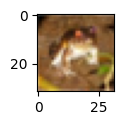

In [9]:
plot_sample(0)

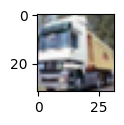

In [10]:
plot_sample(1)

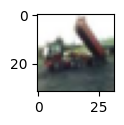

In [11]:
plot_sample(2)

In [12]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

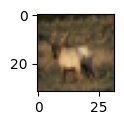

In [13]:
plot_sample(3)

In [14]:
classes[y_train[3][0]]

'deer'

In [15]:
y_train[:3]

array([[6],
       [9],
       [9]], dtype=uint8)

In [16]:
y_test.shape

(10000, 1)

In [17]:
X_train.shape

(50000, 32, 32, 3)

# Preprocessing: Scale images

In [18]:
X_train_scaled = X_train / 255
X_test_scaled = X_test / 255

In [21]:
y_train_categorical = keras.utils.to_categorical(
    y_train, num_classes=10
)
y_test_categorical = keras.utils.to_categorical(
    y_test, num_classes=10
)

In [22]:
y_train[0:5]

array([[6],
       [9],
       [9],
       [4],
       [1]], dtype=uint8)

In [23]:
y_train_categorical[0:5]

array([[0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.]])

# Model building and training

In [24]:
model = keras.Sequential([
        keras.layers.Flatten(input_shape=(32,32,3)),
        keras.layers.Dense(3000, activation='relu'),
        keras.layers.Dense(1000, activation='relu'),
        keras.layers.Dense(10, activation='sigmoid')
    ])

model.compile(optimizer='SGD',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

model.fit(X_train_scaled, y_train_categorical, epochs=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 84ms/step - accuracy: 0.3553 - loss: 1.8091


# Let's make some predictions

In [25]:
np.argmax(model.predict(X_test_scaled)[0])

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 24ms/step


np.int64(3)

In [26]:
y_test[0]

array([3], dtype=uint8)

In [27]:
def get_model():
    model = keras.Sequential([
            keras.layers.Flatten(input_shape=(32,32,3)),
            keras.layers.Dense(3000, activation='relu'),
            keras.layers.Dense(1000, activation='relu'),
            keras.layers.Dense(10, activation='sigmoid')
        ])

    model.compile(optimizer='SGD',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# Measure training time on a CPU

In [28]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 132s 84ms/step - accuracy: 0.3508 - loss: 1.8191
2min 24s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


# Lets measure training time on a GPU

In [29]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=1)

1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 87ms/step - accuracy: 0.3521 - loss: 1.8146
2min 18s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


# Lets run same test for 10 epocs

In [30]:
%%timeit -n1 -r1
with tf.device('/CPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 91ms/step - accuracy: 0.3526 - loss: 1.8143
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 87ms/step - accuracy: 0.4271 - loss: 1.6253
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 87ms/step - accuracy: 0.4555 - loss: 1.5426
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.4752 - loss: 1.4825
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 135s 87ms/step - accuracy: 0.4967 - loss: 1.4317
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - accuracy: 0.5107 - loss: 1.3912
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 136s 87ms/step - accuracy: 0.5248 - loss: 1.3522
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 87ms/step - accuracy: 0.5369 - loss: 1.3147
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 88ms/step - accuracy: 0.5505 - loss: 1.2822
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 150s 93ms/step - accuracy: 0.5613 - loss: 1.2515
23min 29s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)


In [31]:
%%timeit -n1 -r1
with tf.device('/GPU:0'):
    cpu_model = get_model()
    cpu_model.fit(X_train_scaled, y_train_categorical, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 141s 90ms/step - accuracy: 0.3558 - loss: 1.8127
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.4270 - loss: 1.6244
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 194s 89ms/step - accuracy: 0.4569 - loss: 1.5409
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.4764 - loss: 1.4812
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 138s 88ms/step - accuracy: 0.4939 - loss: 1.4331
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 146s 93ms/step - accuracy: 0.5115 - loss: 1.3854
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 137s 88ms/step - accuracy: 0.5247 - loss: 1.3505
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 142s 88ms/step - accuracy: 0.5365 - loss: 1.3159
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 143s 88ms/step - accuracy: 0.5492 - loss: 1.2832
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 144s 92ms/step - accuracy: 0.5595 - loss: 1.2518
24min 33s ± 0 ns per loop (mean ± std. dev. of 1 run, 1 loop each)
